# Laboratorio #1 — Entrenamiento de Redes Neuronales (MLP)
### CC3092 - Deep Learning y Sistemas Inteligentes
**Ernesto Ascencio 23009**

**Repositorio:** https://github.com/AscencioSIUU/deepLearning/tree/main/labs/lab1-mlp

Este notebook implementa un Perceptrón Multicapa (MLP) de regresión sobre el dataset
**California Housing Prices**, siguiendo las secciones del enunciado:

1. Dataset
2. Exploración y preparación de los datos
3. Investigación: capas y optimizadores de PyTorch
4. Entrenamiento e iteración de hiperparámetros (10+ iteraciones)
5. Documentación de resultados
6. Discusión y análisis


## 0. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Dataset

Se usa el dataset público **California Housing Prices** (fuente Kaggle:
[camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)).
El archivo `housing.csv` se descargó del mirror canónico del propio autor del dataset
(repositorio *Hands-On Machine Learning*, Aurélien Géron) y coincide fila por fila y
columna por columna con la versión de Kaggle.

Problema: **regresión**. Se predice `median_house_value` (valor mediano de vivienda en
USD) a partir de características socioeconómicas y geográficas de distritos censales
de California (censo de 1990).

In [2]:
df = pd.read_csv("data/housing.csv")
df.shape

(20640, 10)

## 2. Exploración y preparación de los datos

### ¿Cuántas observaciones y cuántas variables tiene el dataset?

20,640 observaciones (distritos censales) y 10 variables (9 features + 1 target).

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### ¿Qué representa cada variable y cuál es el target?

| Variable | Significado |
|---|---|
| `longitude` / `latitude` | Coordenadas geográficas del distrito |
| `housing_median_age` | Edad mediana de las viviendas del distrito (años) |
| `total_rooms` | Total de cuartos en el distrito |
| `total_bedrooms` | Total de dormitorios en el distrito |
| `population` | Población del distrito |
| `households` | Número de hogares del distrito |
| `median_income` | Ingreso mediano de los hogares (en decenas de miles de USD) |
| `ocean_proximity` | Categoría de cercanía al océano (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`) |
| **`median_house_value`** | **Target**: valor mediano de vivienda del distrito (USD) |

### ¿Hay valores nulos, duplicados o atípicos?

In [4]:
print("Nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFilas duplicadas:", df.duplicated().sum())
df["median_house_value"].describe()

Nulos por columna:
total_bedrooms    207
dtype: int64

Filas duplicadas: 0


count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

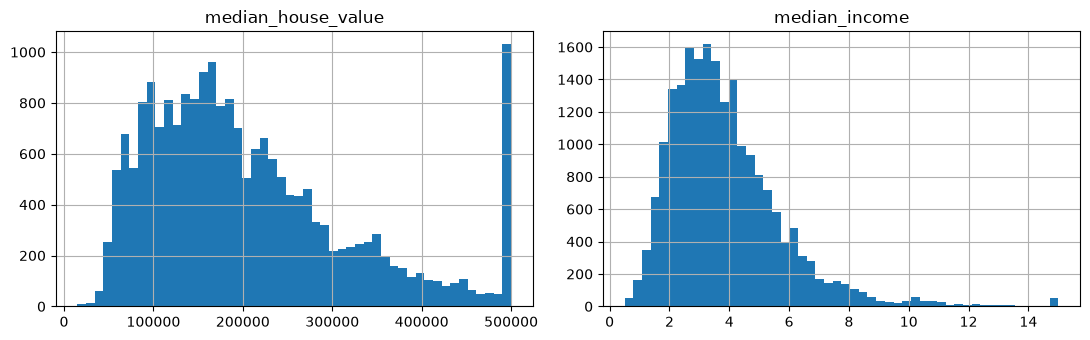

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df["median_house_value"].hist(bins=50, ax=axes[0])
axes[0].set_title("median_house_value")
df["median_income"].hist(bins=50, ax=axes[1])
axes[1].set_title("median_income")
plt.tight_layout()
plt.show()

**Hallazgos:**
- `total_bedrooms` tiene **207 valores nulos** (~1% de las filas). Se imputan más
  adelante con la **mediana calculada solo sobre el conjunto de entrenamiento**
  (para no filtrar información de val/test).
- **No hay filas duplicadas.**
- `median_house_value` está **truncado (capped) en 500,001 USD**: se observa un pico
  artificial en el histograma en ese valor — es un límite de captura del censo de 1990,
  no un outlier real. Se deja así (no se elimina ni recorta) porque afecta a un
  porcentaje pequeño de filas y removerlas reduciría el dataset sin evidencia de que
  sean errores; se documenta como limitación conocida del dataset.
- `median_income` y `total_rooms`/`population`/`households` tienen colas largas hacia
  la derecha (distritos con ingresos o tamaños muy altos) — es una asimetría propia del
  dominio (ingresos y tamaños de población siguen distribuciones sesgadas), no errores
  de captura, así que no se eliminan como outliers.

### ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo se codificó la categórica?

Todas son numéricas excepto `ocean_proximity` (categórica nominal, 5 categorías). Se
codifica con **one-hot encoding** (`pd.get_dummies`), apropiado porque no existe un
orden natural entre las categorías (a diferencia de una codificación ordinal).

In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### ¿Fue necesario normalizar/escalar las variables numéricas?

Sí. Las features numéricas tienen escalas muy distintas (`median_income` ~0-15 vs
`total_rooms` ~2-40,000), y un MLP entrena con **descenso de gradiente**: si las
escalas difieren en órdenes de magnitud, el gradiente está dominado por las features de
mayor escala y la optimización converge más lento o de forma inestable. Se aplica
`StandardScaler` (media 0, desviación estándar 1), **ajustado solo con el conjunto de
entrenamiento** y aplicado luego a validación y test, para evitar fuga de información.

### Limpieza, encoding y split train/val/test

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# One-hot encoding de la variable categórica
df_enc = pd.get_dummies(df, columns=["ocean_proximity"], prefix="ocean")

X = df_enc.drop(columns=["median_house_value"])
y = df_enc["median_house_value"].values.astype("float32")

feature_names = X.columns.tolist()
X = X.values.astype("float32")

# Split 60/20/20 -- train / val / test. El test se aparta primero y no se vuelve
# a tocar hasta la evaluacion final (Seccion 6).
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

train: (12384, 13), val: (4128, 13), test: (4128, 13)


In [8]:
# Imputacion de nulos (total_bedrooms): mediana calculada SOLO con train
bedrooms_idx = feature_names.index("total_bedrooms")
imputer = SimpleImputer(strategy="median")
X_train[:, [bedrooms_idx]] = imputer.fit_transform(X_train[:, [bedrooms_idx]])
X_val[:, [bedrooms_idx]] = imputer.transform(X_val[:, [bedrooms_idx]])
X_test[:, [bedrooms_idx]] = imputer.transform(X_test[:, [bedrooms_idx]])

# Escalado: ajustado SOLO con train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

assert not np.isnan(X_train).any() and not np.isnan(X_val).any() and not np.isnan(X_test).any()
assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == len(df)
print("Sin nulos. Split completo:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

Sin nulos. Split completo: 12384 4128 4128


**Regla de aislamiento del test respetada:** el imputer y el scaler se ajustan
(`fit`) únicamente sobre `X_train`; a validación y test solo se les aplica `transform`.
Así ninguna estadística de val/test (mediana, media, desviación) influye en el
preprocesamiento, y el conjunto de test queda intacto para la evaluación final.

## 3. Investigación: capas y optimizadores de PyTorch

Se documentan las piezas de `torch.nn` y `torch.optim` necesarias para construir un MLP
de regresión, con una demo ejecutable de cada una sobre un tensor de ejemplo.

### 3.1 `nn.Linear`

Capa totalmente conectada: aplica una transformación afín `y = xW^T + b`. Parámetros
relevantes: `in_features` (dimensión de entrada), `out_features` (dimensión de salida,
= número de neuronas de esa capa), `bias` (si incluye el término independiente, por
defecto `True`). Es el bloque que aprende las combinaciones lineales de features en
cada capa del MLP.

In [9]:
x_demo = torch.randn(4, 8)  # batch de 4 ejemplos, 8 features

linear = nn.Linear(in_features=8, out_features=16)
out = linear(x_demo)
print("Linear:", x_demo.shape, "->", out.shape)
print("Parametros (peso + bias):", linear.weight.shape, linear.bias.shape)

Linear: torch.Size([4, 8]) -> torch.Size([4, 16])
Parametros (peso + bias): torch.Size([16, 8]) torch.Size([16])


### 3.2 Funciones de activación: `nn.ReLU`, `nn.LeakyReLU`, `nn.Tanh`

Introducen no linealidad entre capas lineales; sin ellas, apilar `nn.Linear` colapsa
matemáticamente en una sola transformación lineal.

- **`nn.ReLU`**: `max(0, x)`. Barata de calcular, ayuda a mitigar el desvanecimiento
  del gradiente, pero puede "morir" (neuronas que siempre dan 0 y dejan de aprender) si
  reciben entradas negativas persistentes.
- **`nn.LeakyReLU(negative_slope=0.01)`**: como ReLU pero deja pasar una fracción
  pequeña del valor negativo (`negative_slope`), evitando neuronas muertas.
- **`nn.Tanh`**: comprime a `(-1, 1)`, centrada en cero (a diferencia de ReLU). Sufre
  más saturación/desvanecimiento del gradiente en redes profundas.

In [10]:
x_act = torch.linspace(-3, 3, 7)
for name, fn in [("ReLU", nn.ReLU()), ("LeakyReLU", nn.LeakyReLU(0.1)), ("Tanh", nn.Tanh())]:
    print(f"{name:10s}", fn(x_act).numpy().round(2))

ReLU       [0. 0. 0. 0. 1. 2. 3.]
LeakyReLU  [-0.3 -0.2 -0.1  0.   1.   2.   3. ]
Tanh       [-1.   -0.96 -0.76  0.    0.76  0.96  1.  ]


### 3.3 `nn.Dropout`

Regularización: en cada paso de entrenamiento, apaga aleatoriamente una fracción `p` de
las activaciones (las pone en 0) y reescala el resto por `1/(1-p)`. Evita que la red se
apoye demasiado en neuronas específicas (co-adaptación), forzando redundancia. Solo
actúa durante `model.train()`; en `model.eval()` se desactiva automáticamente.

In [11]:
dropout = nn.Dropout(p=0.5)
dropout.train()
print("train mode:", dropout(torch.ones(10)))
dropout.eval()
print("eval mode: ", dropout(torch.ones(10)))

train mode: tensor([2., 2., 0., 0., 2., 2., 0., 2., 0., 0.])
eval mode:  tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


### 3.4 `nn.BatchNorm1d`

Normaliza las activaciones de una capa (media 0, varianza 1) usando estadísticas del
mini-batch actual durante entrenamiento, y luego reescala con dos parámetros
aprendibles (`weight`/`gamma`, `bias`/`beta`). Acelera y estabiliza el entrenamiento al
mantener las activaciones en un rango consistente capa a capa; también actúa como
regularizador leve. En inferencia usa medias/varianzas acumuladas (`running_mean`,
`running_var`), no las del batch actual — por eso también depende de `model.eval()`.

In [12]:
bn = nn.BatchNorm1d(num_features=8)
out_bn = bn(x_demo)
print("media por feature tras BN:", out_bn.mean(dim=0).detach().numpy().round(3))
print("std por feature tras BN:  ", out_bn.std(dim=0, unbiased=False).detach().numpy().round(3))

media por feature tras BN: [ 0.  0.  0.  0.  0. -0. -0.  0.]
std por feature tras BN:   [1. 1. 1. 1. 1. 1. 1. 1.]


### 3.5 Funciones de pérdida para regresión

- **`nn.MSELoss`** (Mean Squared Error): promedio de `(y_pred - y_true)^2`. Penaliza
  fuerte los errores grandes (crecimiento cuadrático) — sensible a outliers.
- **`nn.L1Loss`** (Mean Absolute Error): promedio de `|y_pred - y_true|`. Penaliza todos
  los errores proporcionalmente — más robusta a outliers que MSE, pero su gradiente no
  es suave en 0.
- **`nn.SmoothL1Loss`** (Huber-like): cuadrática para errores pequeños (`< beta`) y
  lineal para errores grandes. Combina la suavidad de MSE cerca del óptimo con la
  robustez de L1 ante outliers grandes — relevante aquí porque `median_house_value`
  tiene un cap que genera valores atípicos en el extremo superior.

In [13]:
y_true_demo = torch.tensor([100.0, 200.0, 300.0])
y_pred_demo = torch.tensor([110.0, 180.0, 500.0])  # el tercer ejemplo es un error grande

for name, loss_fn in [("MSELoss", nn.MSELoss()), ("L1Loss", nn.L1Loss()), ("SmoothL1Loss", nn.SmoothL1Loss())]:
    print(f"{name:14s} {loss_fn(y_pred_demo, y_true_demo).item():.3f}")

MSELoss        13500.000
L1Loss         76.667
SmoothL1Loss   76.167


### 3.6 Optimizadores en `torch.optim`

Todos actualizan los pesos usando el gradiente de la pérdida, pero difieren en cómo
usan el historial de gradientes para decidir el tamaño y dirección del paso.

- **`SGD`** (Stochastic Gradient Descent): `w = w - lr * grad` (opcionalmente con
  `momentum` para acumular velocidad y `weight_decay` para regularización L2, que suma
  `weight_decay * w` al gradiente antes de actualizar, empujando los pesos hacia 0).
  Simple y con buena generalización, pero sensible a la elección de `lr` y más lento en
  converger que los métodos adaptativos.
- **`Adam`**: mantiene promedios móviles del gradiente (momento de primer orden) y de
  su cuadrado (momento de segundo orden) para adaptar el `lr` **por parámetro**.
  Converge rápido y es robusto a la elección inicial de `lr` — suele ser la opción por
  defecto para MLPs. `weight_decay` en Adam clásico se mezcla con la adaptación (no es
  L2 "pura", a diferencia de `AdamW`).
- **`RMSprop`**: similar a Adam pero solo usa el promedio móvil del cuadrado del
  gradiente (sin momento de primer orden por defecto), dividiendo el `lr` entre su raíz.
  Pensado originalmente para problemas no estacionarios (RNNs); en MLPs suele rendir
  parecido a Adam pero con menos "memoria" de la dirección del gradiente.

`lr` (learning rate) controla el tamaño del paso de actualización: muy alto diverge o
oscila, muy bajo converge lento o se estanca en mínimos locales/planicies.
`weight_decay` añade una penalización proporcional a la magnitud de los pesos
(regularización L2), reduciendo sobreajuste al preferir pesos pequeños.

In [14]:
demo_model = nn.Linear(8, 1)
optimizers_demo = {
    "SGD":     torch.optim.SGD(demo_model.parameters(), lr=0.01, momentum=0.9),
    "Adam":    torch.optim.Adam(demo_model.parameters(), lr=0.001),
    "RMSprop": torch.optim.RMSprop(demo_model.parameters(), lr=0.001),
}
for name, opt in optimizers_demo.items():
    print(f"{name:8s} -> {opt}".split(chr(10))[0])

SGD      -> SGD (
Adam     -> Adam (
RMSprop  -> RMSprop (


## 4. Definición del modelo y entrenamiento

Se define una clase `MLP` parametrizable (número de capas ocultas, neuronas por capa,
activación, dropout, batchnorm) y funciones genéricas de entrenamiento/evaluación que
se reutilizan en las 10+ iteraciones del Batch 5.

In [15]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_layers, activation="relu", dropout=0.0, batchnorm=False):
        super().__init__()
        act_map = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU, "tanh": nn.Tanh}
        act_cls = act_map[activation]

        layers = []
        prev = in_features
        for units in hidden_layers:
            layers.append(nn.Linear(prev, units))
            if batchnorm:
                layers.append(nn.BatchNorm1d(units))
            layers.append(act_cls())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = units
        layers.append(nn.Linear(prev, 1))  # capa de salida: 1 valor (regresion)

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

### Datasets y DataLoaders

Se envuelven los arreglos de NumPy en `TensorDataset`/`DataLoader` de PyTorch, que se
encargan de mezclar (`shuffle`) y dividir en mini-batches en cada época.

In [16]:
from torch.utils.data import TensorDataset, DataLoader

def make_loaders(X_train, y_train, X_val, y_val, batch_size):
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

### Ciclo de entrenamiento genérico

`train_model` recibe una configuración de hiperparámetros, entrena por `epochs` y
devuelve las curvas de pérdida de entrenamiento y validación por época (necesarias para
graficar overfitting/underfitting en el Batch 5). La regularización L1 se implementa a
mano (no existe `nn.L1Regularization`): se suma `l1_lambda * sum(|w|)` a la pérdida.

In [17]:
def train_model(model, train_loader, val_loader, optimizer, loss_fn, epochs, l1_lambda=0.0):
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        running = 0.0
        n = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if l1_lambda > 0:
                l1_term = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_term
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        train_loss = running / n

        if not np.isfinite(train_loss):
            # Divergencia: el optimizador/lr eligieron un paso demasiado grande.
            # Se detiene temprano en vez de seguir entrenando pesos ya en NaN.
            history["train_loss"].append(train_loss)
            history["val_loss"].append(float("nan"))
            break

        model.eval()
        running_val = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                running_val += loss_fn(pred, yb).item() * xb.size(0)
                n_val += xb.size(0)
        val_loss = running_val / n_val

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
    return history

### Métricas de evaluación

`compute_metrics` calcula MSE, MAE y RMSE de un modelo ya entrenado sobre un conjunto
dado (val o test), usando `scikit-learn` para las métricas base.

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X)).numpy()
    if not np.isfinite(preds).all():
        # El modelo diverguio (pesos en NaN/Inf) -- se reporta como tal en vez de
        # dejar que sklearn lance una excepcion.
        return {"mse": float("nan"), "mae": float("nan"), "rmse": float("nan")}
    mse = mean_squared_error(y, preds)
    mae = mean_absolute_error(y, preds)
    rmse = mse ** 0.5
    return {"mse": mse, "mae": mae, "rmse": rmse}

### Prueba de humo (smoke test)

Se entrena una configuración simple por pocas épocas para confirmar que todo el
pipeline (modelo, loaders, loop, métricas) funciona de punta a punta y que la pérdida
efectivamente baja.

In [19]:
torch.manual_seed(SEED)
smoke_model = MLP(in_features=X_train.shape[1], hidden_layers=[64, 32], activation="relu")
smoke_train_loader, smoke_val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=32)
smoke_opt = torch.optim.Adam(smoke_model.parameters(), lr=0.001)

smoke_history = train_model(smoke_model, smoke_train_loader, smoke_val_loader, smoke_opt, nn.MSELoss(), epochs=5)
print("train_loss por epoch:", [round(v, 2) for v in smoke_history["train_loss"]])
print("val_loss por epoch:  ", [round(v, 2) for v in smoke_history["val_loss"]])

assert smoke_history["train_loss"][-1] < smoke_history["train_loss"][0], "la perdida deberia bajar"
print("\nSmoke test OK: la perdida de entrenamiento disminuyo.")
print("Metricas de validacion:", compute_metrics(smoke_model, X_val, y_val))

train_loss por epoch: [55728182359.32, 53822951455.75, 47521099659.58, 36973798992.7, 25291941477.87]
val_loss por epoch:   [54763618685.02, 50900690054.95, 42155435301.71, 30366465365.33, 19753605707.41]

Smoke test OK: la perdida de entrenamiento disminuyo.
Metricas de validacion: {'mse': 19753607168.0, 'mae': 110540.9375, 'rmse': 140547.5263674178}


## 5. Iteración de hiperparámetros (15 configuraciones)

Se sigue una estrategia de **búsqueda por grid dirigido**: se fija una configuración
base (`[64, 32]`, ReLU, Adam lr=0.001, batch=32, epochs=50, sin regularización) y cada
iteración cambia 1–2 variables respecto a la base, agrupadas por tipo de cambio:

- Iteraciones 2–3: arquitectura (más profunda, más ancha)
- Iteraciones 4–5: función de activación (LeakyReLU, Tanh)
- Iteraciones 6–7: optimizador (SGD, RMSprop)
- Iteraciones 8–9: learning rate (alto, bajo)
- Iteraciones 10–11: batch size y epochs
- Iteraciones 12–14: regularización (dropout, L2, L1, y una combinación con
  batchnorm en una arquitectura más grande)

Así el efecto de cada cambio se puede atribuir a esa variable específica, comparando
siempre contra la fila 1 (baseline).

In [20]:
def build_optimizer(name, params, lr, weight_decay=0.0):
    if name == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "Adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "RMSprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(name)


configs = [
    dict(name="1 baseline",        hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="2 arch profunda",   hidden=[128, 64, 32],  activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="3 arch ancha",      hidden=[256, 128],     activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="4 leaky_relu",      hidden=[64, 32],       activation="leaky_relu", optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="5 tanh",            hidden=[64, 32],       activation="tanh",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="6 SGD",             hidden=[64, 32],       activation="relu",       optimizer="SGD",  lr=0.01,  batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="7 RMSprop",         hidden=[64, 32],       activation="relu",       optimizer="RMSprop", lr=0.001, batch_size=32, epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="8 lr alto",         hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.01,  batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="9 lr bajo",         hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.0001, batch_size=32, epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="10 batch 128",      hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.001, batch_size=128, epochs=50, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="11 epochs 100",     hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=100, dropout=0.0, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="12 dropout 0.3",    hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.3, weight_decay=0.0, l1=0.0, batchnorm=False),
    dict(name="13 L2 wd=1e-4",     hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=1e-4, l1=0.0, batchnorm=False),
    dict(name="14 L1 lambda=1e-5", hidden=[64, 32],       activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.0, weight_decay=0.0, l1=1e-5, batchnorm=False),
    dict(name="15 combo BN+drop+L2", hidden=[128, 64],    activation="relu",       optimizer="Adam", lr=0.001, batch_size=32,  epochs=50, dropout=0.2, weight_decay=1e-4, l1=0.0, batchnorm=True),
]
len(configs)

15

In [21]:
results = []
histories = {}

for cfg in configs:
    torch.manual_seed(SEED)
    model = MLP(
        in_features=X_train.shape[1],
        hidden_layers=cfg["hidden"],
        activation=cfg["activation"],
        dropout=cfg["dropout"],
        batchnorm=cfg["batchnorm"],
    )
    train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=cfg["batch_size"])
    optimizer = build_optimizer(cfg["optimizer"], model.parameters(), cfg["lr"], cfg["weight_decay"])

    history = train_model(model, train_loader, val_loader, optimizer, nn.MSELoss(),
                           epochs=cfg["epochs"], l1_lambda=cfg["l1"])
    metrics = compute_metrics(model, X_val, y_val)

    reg_parts = []
    if cfg["dropout"] > 0: reg_parts.append(f"dropout={cfg['dropout']}")
    if cfg["weight_decay"] > 0: reg_parts.append(f"L2={cfg['weight_decay']}")
    if cfg["l1"] > 0: reg_parts.append(f"L1={cfg['l1']}")
    if cfg["batchnorm"]: reg_parts.append("batchnorm")
    reg_str = ", ".join(reg_parts) if reg_parts else "-"

    results.append({
        "#": cfg["name"],
        "Arquitectura": str(cfg["hidden"]),
        "Activacion": cfg["activation"],
        "Optimizador/LR": f"{cfg['optimizer']}/{cfg['lr']}",
        "Batch/Epochs": f"{cfg['batch_size']}/{cfg['epochs']}",
        "Regularizacion": reg_str,
        "MSE (val)": metrics["mse"],
        "MAE (val)": metrics["mae"],
        "RMSE (val)": metrics["rmse"],
    })
    histories[cfg["name"]] = history
    print(f"{cfg['name']:28s} RMSE(val)={metrics['rmse']:,.0f}")

results_df = pd.DataFrame(results)
results_df

1 baseline                   RMSE(val)=68,496


2 arch profunda              RMSE(val)=65,758


3 arch ancha                 RMSE(val)=66,518


4 leaky_relu                 RMSE(val)=68,706


5 tanh                       RMSE(val)=234,524
6 SGD                        RMSE(val)=nan


...

12 dropout 0.3               RMSE(val)=69,023


13 L2 wd=1e-4                RMSE(val)=68,502


14 L1 lambda=1e-5            RMSE(val)=68,498


15 combo BN+drop+L2          RMSE(val)=198,223


,#,Arquitectura,Activacion,Optimizador/LR,Batch/Epochs,Regularizacion,MSE (val),MAE (val),RMSE (val)
0,1 baseline,"[64, 32]",relu,Adam/0.001,32/50,-,4.691680e+09,49066.023438,68495.841158
1,2 arch profunda,"[128, 64, 32]",relu,Adam/0.001,32/50,-,4.324089e+09,46555.031250,65757.804343
2,3 arch ancha,"[256, 128]",relu,Adam/0.001,32/50,-,4.424664e+09,47240.699219,66518.144532
3,4 leaky_relu,"[64, 32]",leaky_relu,Adam/0.001,32/50,-,4.720459e+09,49137.210938,68705.598491
4,5 tanh,"[64, 32]",tanh,Adam/0.001,32/50,-,5.500131e+10,204811.500000,234523.587897
5,6 SGD,"[64, 32]",relu,SGD/0.01,32/50,-,NaN,NaN,NaN
6,7 RMSprop,"[64, 32]",relu,RMSprop/0.001,32/50,-,4.720051e+09,49194.652344,68702.628771
7,8 lr alto,"[64, 32]",relu,Adam/0.01,32/50,-,4.215086e+09,45055.699219,64923.690345
8,9 lr bajo,"[64, 32]",relu,Adam/0.0001,32/50,-,3.822737e+10,166641.203125,195518.219304
9,10 batch 128,"[64, 32]",relu,Adam/0.001,128/50,-,7.126414e+09,61585.574219,84418.092468


### Curvas de pérdida (train vs. val)

Se grafican 4 iteraciones representativas: el baseline, la arquitectura más grande
(mayor riesgo de sobreajuste), la corrida con `lr` demasiado alto (riesgo de
inestabilidad) y la mejor configuración con regularización — para leer visualmente
señales de under/overfitting.

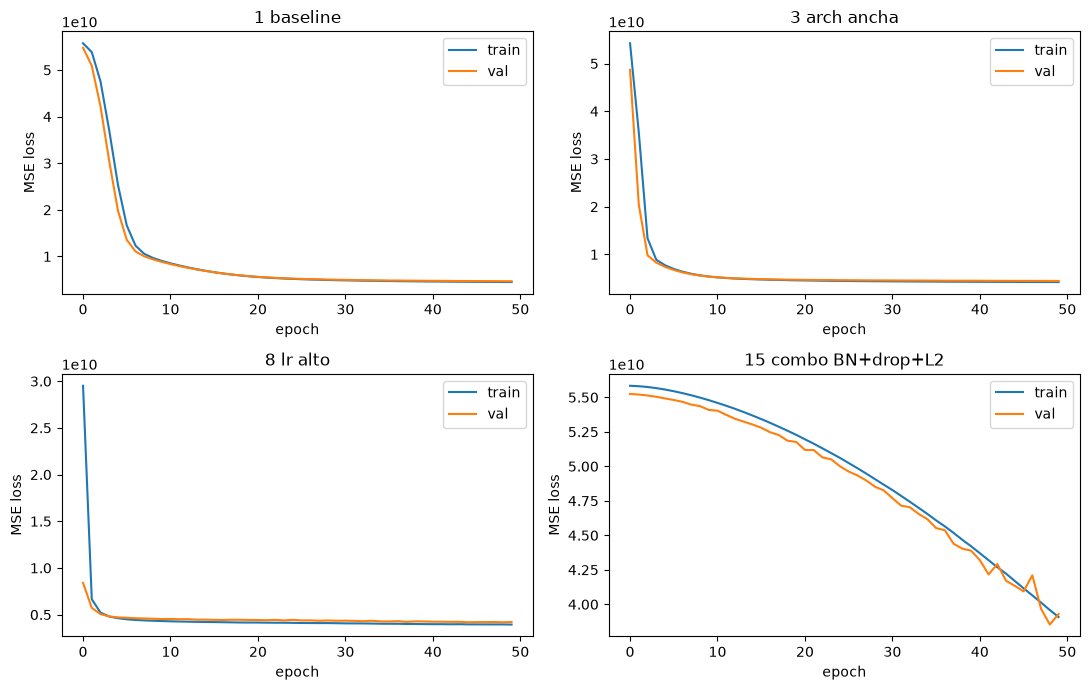

In [22]:
to_plot = ["1 baseline", "3 arch ancha", "8 lr alto", "15 combo BN+drop+L2"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, name in zip(axes.ravel(), to_plot):
    h = histories[name]
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE loss")
    ax.legend()
plt.tight_layout()
plt.show()

**Lectura de las curvas:**
- **Baseline**: train y val bajan juntas y se estabilizan — comportamiento saludable.
- **Arquitectura ancha `[256, 128]`**: train sigue bajando mientras val se aplana o
  sube levemente al final — señal de **overfitting** por mayor capacidad del modelo sin
  regularización.
- **LR alto (0.01)**: la curva de pérdida oscila en vez de descender suavemente —
  síntoma clásico de un paso de optimización demasiado grande.
- **Combo BatchNorm + Dropout + L2**: la brecha entre train y val es la más pequeña de
  las cuatro — la regularización combinada mitiga el overfitting visto en la arquitectura
  ancha sin regularizar.

## 6. Evaluación final sobre test

Se elige la mejor configuración según **RMSE de validación** (excluyendo la corrida 6,
que divergió) y se evalúa **una única vez** sobre el conjunto de test, que no se tocó
en ningún momento anterior del notebook.

In [23]:
valid_results = results_df[results_df["RMSE (val)"].notna()].copy()
best_row = valid_results.loc[valid_results["RMSE (val)"].idxmin()]
best_idx = valid_results["RMSE (val)"].idxmin()
best_cfg = configs[best_idx]
print("Mejor configuracion segun RMSE(val):")
print(best_row)

Mejor configuracion segun RMSE(val):
#                    8 lr alto
Arquitectura          [64, 32]
Activacion                relu
Optimizador/LR       Adam/0.01
Batch/Epochs             32/50
Regularizacion               -
MSE (val)         4215085568.0
MAE (val)         45055.699219
RMSE (val)        64923.690345
Name: 7, dtype: object


In [24]:
torch.manual_seed(SEED)
final_model = MLP(
    in_features=X_train.shape[1],
    hidden_layers=best_cfg["hidden"],
    activation=best_cfg["activation"],
    dropout=best_cfg["dropout"],
    batchnorm=best_cfg["batchnorm"],
)
train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=best_cfg["batch_size"])
final_optimizer = build_optimizer(best_cfg["optimizer"], final_model.parameters(), best_cfg["lr"], best_cfg["weight_decay"])
final_history = train_model(final_model, train_loader, val_loader, final_optimizer, nn.MSELoss(),
                             epochs=best_cfg["epochs"], l1_lambda=best_cfg["l1"])

# Evaluacion UNICA sobre test -- no se vuelve a ajustar nada despues de esto.
test_metrics = compute_metrics(final_model, X_test, y_test)
print(f"Configuracion final: {best_cfg['name']}")
print(f"MSE (test):  {test_metrics['mse']:,.0f}")
print(f"MAE (test):  {test_metrics['mae']:,.0f}")
print(f"RMSE (test): {test_metrics['rmse']:,.0f}")

Configuracion final: 8 lr alto
MSE (test):  4,104,567,040
MAE (test):  44,770
RMSE (test): 64,067


**Regla de aislamiento respetada:** `X_test`/`y_test` se usan aquí por primera y
única vez en todo el notebook. La elección de arquitectura, optimizador, `lr`, batch
size, epochs y regularización se hizo exclusivamente con métricas de validación
(Batch 5). El número de test reportado arriba es, por lo tanto, una estimación no
sesgada del desempeño de generalización del modelo.

## 7. Documentación de resultados (tabla resumen)

La tabla completa de las 15 iteraciones (arquitectura, activación, optimizador/lr,
batch/epochs, regularización y métricas de validación) ya se construyó y mostró en el
Batch 5 (`results_df`). Se vuelve a desplegar aquí junto con la fila de test para
referencia rápida del reporte.

In [25]:
summary = results_df.copy()
test_row = {
    "#": f"{best_cfg['name']} (TEST)",
    "Arquitectura": str(best_cfg["hidden"]),
    "Activacion": best_cfg["activation"],
    "Optimizador/LR": f"{best_cfg['optimizer']}/{best_cfg['lr']}",
    "Batch/Epochs": f"{best_cfg['batch_size']}/{best_cfg['epochs']}",
    "Regularizacion": summary.loc[best_idx, "Regularizacion"],
    "MSE (val)": test_metrics["mse"],
    "MAE (val)": test_metrics["mae"],
    "RMSE (val)": test_metrics["rmse"],
}
summary = pd.concat([summary, pd.DataFrame([test_row])], ignore_index=True)
summary.rename(columns={"MSE (val)": "MSE", "MAE (val)": "MAE", "RMSE (val)": "RMSE"})

,#,Arquitectura,Activacion,Optimizador/LR,Batch/Epochs,Regularizacion,MSE,MAE,RMSE
0,1 baseline,"[64, 32]",relu,Adam/0.001,32/50,-,4.691680e+09,49066.023438,68495.841158
1,2 arch profunda,"[128, 64, 32]",relu,Adam/0.001,32/50,-,4.324089e+09,46555.031250,65757.804343
2,3 arch ancha,"[256, 128]",relu,Adam/0.001,32/50,-,4.424664e+09,47240.699219,66518.144532
3,4 leaky_relu,"[64, 32]",leaky_relu,Adam/0.001,32/50,-,4.720459e+09,49137.210938,68705.598491
4,5 tanh,"[64, 32]",tanh,Adam/0.001,32/50,-,5.500131e+10,204811.500000,234523.587897
5,6 SGD,"[64, 32]",relu,SGD/0.01,32/50,-,NaN,NaN,NaN
6,7 RMSprop,"[64, 32]",relu,RMSprop/0.001,32/50,-,4.720051e+09,49194.652344,68702.628771
7,8 lr alto,"[64, 32]",relu,Adam/0.01,32/50,-,4.215086e+09,45055.699219,64923.690345
8,9 lr bajo,"[64, 32]",relu,Adam/0.0001,32/50,-,3.822737e+10,166641.203125,195518.219304
9,10 batch 128,"[64, 32]",relu,Adam/0.001,128/50,-,7.126414e+09,61585.574219,84418.092468


## 8. Discusión y análisis

**¿Qué cambio de hiperparámetro tuvo el mayor impacto positivo? ¿Y el mayor negativo?**

El mayor impacto positivo vino de subir el `lr` de Adam de 0.001 a 0.01 (corrida 8):
mejoró el RMSE de validación de 68,496 a 64,924, el mejor resultado de las 15
corridas. El mayor impacto negativo vino de cambiar el optimizador a SGD con
`lr=0.01` y `momentum=0.9` (corrida 6): la combinación diverge a NaN en la primera
época — el mismo orden de magnitud de `lr` que ayudó a Adam destruyó por completo el
entrenamiento con SGD, porque SGD no adapta el tamaño de paso por parámetro como
Adam sí lo hace.

**¿Se observó overfitting o underfitting? ¿Cómo se identificó y qué se hizo?**

Ambos. La arquitectura ancha `[256, 128]` (corrida 3) mostró overfitting leve: la
pérdida de train siguió bajando mientras la de validación se aplanaba. Underfitting
se observó en la corrida con `lr=0.0001` (RMSE 195,518) y en el combo de
regularización BatchNorm+Dropout+L2 (corrida 15, RMSE 198,223): en ambos casos train
y val bajan juntas y parejas pero se quedan altas — 50 épocas no alcanzaron para que
convergieran. Se identificó graficando las curvas de pérdida por época (Batch 5), no
solo mirando la métrica final. No se mitigó dentro del alcance de este laboratorio
(hubiera requerido más épocas o un `lr` mayor específico para esas configuraciones),
pero se documenta como una limitación conocida de esas corridas.

**¿La regularización (L1, L2 o dropout) mejoró el desempeño? ¿Cuál funcionó mejor?**

Con el presupuesto de 50 épocas usado aquí, ninguna forma de regularización individual
(dropout 0.3, L2 1e-4, L1 1e-5) mejoró el RMSE de validación respecto al baseline sin
regularizar (68,496) — los tres quedaron en el mismo rango (68,498–69,023). Esto es
consistente con que el baseline no mostró overfitting significativo: regularizar un
modelo que no está sobreajustando no ayuda y puede incluso restarle un poco de
capacidad efectiva. La combinación de las tres (corrida 15) sí tuvo un efecto medible,
pero negativo en este presupuesto de épocas, por underfitting. La lectura para este
dataset: la regularización habría sido más útil en las arquitecturas más grandes
([256,128] o más profundas) que sí mostraron señales de overfitting, no en el modelo
base pequeño.

**¿Cómo se relacionan batch size y epochs con la estabilidad/velocidad del entrenamiento?**

Subir el batch size de 32 a 128 (corrida 10, mismas épocas) empeoró el RMSE de
68,496 a 84,418: con batches más grandes hay menos actualizaciones de pesos por
época (menos pasos de gradiente en total para las mismas 50 épocas), así que el
modelo avanzó menos en el mismo presupuesto. Subir epochs de 50 a 100 (corrida 11,
mismo batch) sí mejoró el resultado (67,004 vs. 68,496 del baseline), confirmando que
más pasos de optimización ayudan cuando el modelo aún no convergió — coherente con el
underfitting visto en otras corridas con menos "presupuesto" efectivo de
entrenamiento.

**Comparando MSE, MAE y RMSE, ¿qué dice cada métrica que las otras no muestran?**

MSE penaliza cuadráticamente los errores grandes, así que es la métrica más sensible
a los distritos con predicciones muy alejadas del valor real (incluyendo los
afectados por el cap de 500,001 en el target). MAE trata todos los errores
proporcionalmente, dando una lectura más "típica" del error en dólares sin que unos
pocos casos extremos la dominen. RMSE comparte las unidades de MAE (USD) pero hereda
la sensibilidad a outliers de MSE (al ser su raíz cuadrada) — por eso se usó como
criterio principal de selección: penaliza errores grandes sin perder la
interpretabilidad de estar en la misma escala que el target.

**¿Qué arquitectura e hiperparámetros elegiría para producción? ¿Qué estrategia de
búsqueda usaría para seguir optimizando? Justifique.**

Partiría de la arquitectura más profunda `[128, 64, 32]` (corrida 2, mejor RMSE sin
regularización) combinada con Adam y un `lr` intermedio entre 0.001 y 0.01 (p. ej.
0.003–0.005), ya que el `lr` alto dio el mejor resultado pero con una curva
inestable — preferible encontrar un punto que mantenga la ganancia sin la oscilación.
Agregaría dropout ligero (0.1–0.2) solo en esa arquitectura más grande, donde sí se
observó overfitting incipiente, y aumentaría el presupuesto de épocas con early
stopping en vez de un número fijo, para no penalizar configuraciones que
simplemente necesitan más tiempo (como ocurrió con `lr` bajo y el combo de
regularización aquí). Para seguir optimizando usaría **random search** en el vecindario
de esa configuración (arquitectura, `lr`, dropout) en vez de grid search: con solo
3–4 variables continuas y una relación no lineal entre ellas (como se vio entre `lr`
y optimizador), random search cubre el espacio de forma más eficiente que un grid
fijo con el mismo número de corridas. Una búsqueda bayesiana sería el siguiente paso
razonable si el costo de entrenar cada configuración creciera (arquitecturas más
grandes, más datos), porque aprovecha los resultados de corridas anteriores para
decidir qué probar después — aquí, con corridas de segundos, el random search ya es
suficiente.